In [1]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks, EditedNearestNeighbours as ENN
from imblearn.pipeline import Pipeline as IMBPipeline

from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, classification_report, precision_recall_curve, auc)

from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, LinearSVC
from sklearn.tree import DecisionTreeClassifier


In [2]:
X_train = pd.read_parquet('X_train_final.parquet')
X_test = pd.read_parquet('X_test_final.parquet')
y_train = pd.read_parquet('y_train_final.parquet').iloc[:, 0] # Возвращаем в Series
y_test = pd.read_parquet('y_test_final.parquet').iloc[:, 0]

In [3]:
#Дисбаланс классов - подготовим еще два набора данных , сделанных на основе наших train  данных, методами Under- и OverSampling
y_train.value_counts(normalize=True)

Response
0    0.876596
1    0.123404
Name: proportion, dtype: float64

In [4]:
pipeline_Tomek_ENN = IMBPipeline([
                            ('ENN', ENN(sampling_strategy='majority')),
                            ('tomek', TomekLinks(sampling_strategy='majority'))
                                ])
X_train_Tomek_ENN, y_train_Tomek_ENN = pipeline_Tomek_ENN.fit_resample(X_train, y_train)


pipeline_Tomek_Smote = IMBPipeline([
                            ('smote', SMOTE(sampling_strategy='auto',k_neighbors=10, random_state=42)),
                            ('tomek', TomekLinks(sampling_strategy='majority'))
                                   ])
X_train_Tomek_Smote, y_train_Tomek_Smote = pipeline_Tomek_Smote.fit_resample(X_train, y_train)

In [5]:
y_train_Tomek_ENN.value_counts(normalize=True)

Response
0    0.847371
1    0.152629
Name: proportion, dtype: float64

In [6]:
y_train_Tomek_Smote.value_counts(normalize=True)

Response
1    0.524284
0    0.475716
Name: proportion, dtype: float64

Будем проверять качество моделей на этих трех типах данных(X_train, y_train / X_train_Tomek_Smote, y_train_Tomek_Smote / X_train_Tomek_ENN, y_train_Tomek_ENN).
---

In [7]:
#Создаем функцию для обучения моделей и записи основных метрик качества в отдельную таблицу, для удобства отслеживания
results_table = []
def model_prediction(model, X_tr, y_tr, X_ts, y_ts, experiment_name):
    model.fit(X_tr, y_tr)
    

    y_train_pred = model.predict(X_tr)
    y_test_pred = model.predict(X_ts)
    if 'SVC' not in experiment_name:
        y_test_prob = model.predict_proba(X_ts)[:, 1]

    metrics = {
        'Experiment': experiment_name,
        'Train_Acc': accuracy_score(y_tr, y_train_pred),
        'Test_Acc': accuracy_score(y_ts, y_test_pred),
        'Precision': precision_score(y_ts, y_test_pred),
        'Recall': recall_score(y_ts, y_test_pred),
        'F1_Score': f1_score(y_ts, y_test_pred)
        
    }
    if 'y_test_prob' in locals():
        metrics['ROC_AUC'] = roc_auc_score(y_ts, y_test_prob)
    else:
        metrics['ROC_AUC'] = None
    
    results_table.append(metrics)
    print(model.best_params_)
    cm = confusion_matrix(y_ts, y_test_pred)
    if 'y_test_prob' in locals():
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))

        sns.heatmap(cm, annot=True, fmt="g", cmap="Greens", ax=axes[0])
        axes[0].set_title(f"Модель: {experiment_name}")
    
        precision, recall, threesholds = precision_recall_curve(y_ts, y_test_prob)
        pr_auc = auc(recall, precision)
        axes[1].plot(recall, precision, color='blue', label=f'PR AUC = {pr_auc:.3f}')
        axes[1].set_title(f'Presision-Recall curve {experiment_name}')
        axes[1].set_xlabel("Recall")
        axes[1].set_ylabel("Precision")
        axes[1].legend(loc="lower left")
    else:
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt="g", cmap="Greens")
        plt.title(f"Confusion Matrix: {experiment_name}")
        plt.show()
    
    
    plt.show()
    print(classification_report(y_ts, y_test_pred))


In [8]:
pipeline_LR = IMBPipeline([
                        ('scaler', StandardScaler()),
                        ('classifier', LogisticRegression(max_iter=1001, class_weight='balanced'))
                        ])

grid_params = {
               'classifier__C': [0.0001, 0.001, 0.01, 0.1, 0.5, 1.0]
               
              }

grid_LR = RandomizedSearchCV(
                            estimator=pipeline_LR,
                            param_distributions=grid_params,
                            cv=5,
                            scoring='f1',
                            n_jobs=1,
                            verbose=1
                            )

c:\Users\tsyto\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 5 folds for each of 6 candidates, totalling 30 fits
{'classifier__C': 0.001}


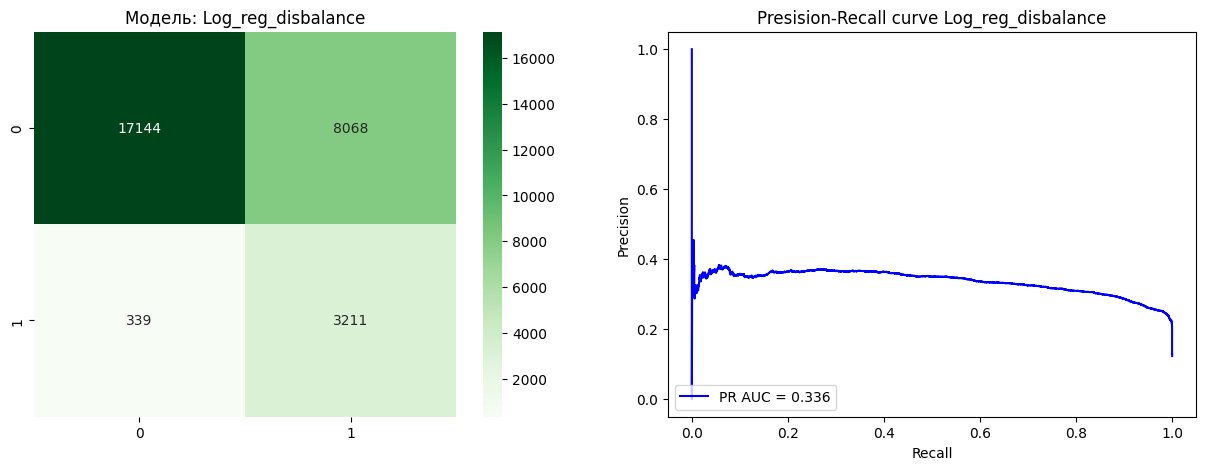

              precision    recall  f1-score   support

           0       0.98      0.68      0.80     25212
           1       0.28      0.90      0.43      3550

    accuracy                           0.71     28762
   macro avg       0.63      0.79      0.62     28762
weighted avg       0.89      0.71      0.76     28762



In [9]:
model_prediction(model=grid_LR, X_tr=X_train, y_tr=y_train, X_ts=X_test, y_ts=y_test, experiment_name='Log_reg_disbalance')

Fitting 5 folds for each of 6 candidates, totalling 30 fits


c:\Users\tsyto\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


{'classifier__C': 0.0001}


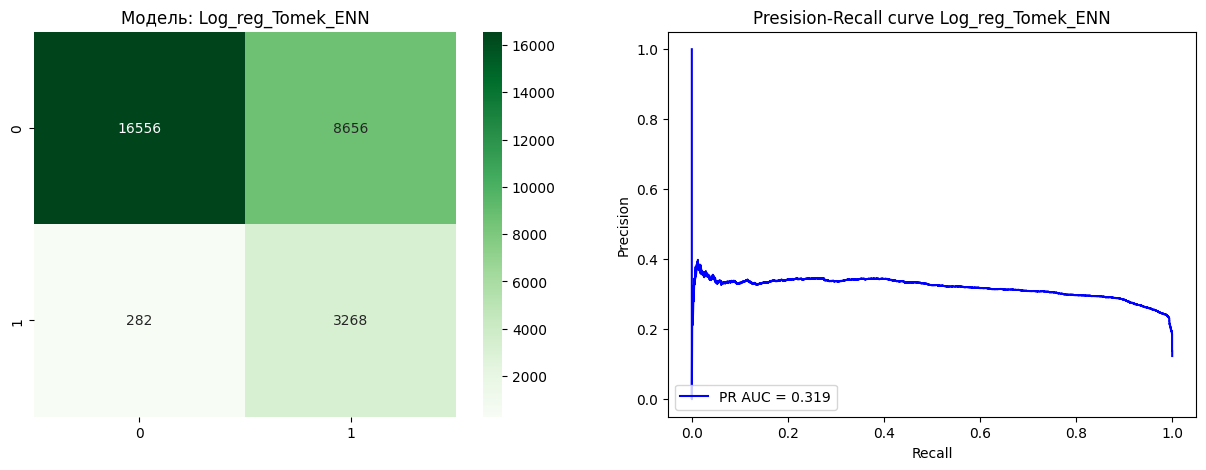

              precision    recall  f1-score   support

           0       0.98      0.66      0.79     25212
           1       0.27      0.92      0.42      3550

    accuracy                           0.69     28762
   macro avg       0.63      0.79      0.60     28762
weighted avg       0.90      0.69      0.74     28762



In [10]:
model_prediction(model=grid_LR, X_tr=X_train_Tomek_ENN, y_tr= y_train_Tomek_ENN, X_ts=X_test, y_ts=y_test, experiment_name='Log_reg_Tomek_ENN')

In [11]:
#Уберем class_weight='balanced', так как SMOTE сделал синтетические данные и по сути дисбаланса класса в этих обучающих данных не будет
pipeline_LR_smote = IMBPipeline([
                        ('scaler', StandardScaler()),
                        ('classifier', LogisticRegression(max_iter=1001))
                        ])          

grid_LR_smote = RandomizedSearchCV(
                            estimator=pipeline_LR_smote,
                            param_distributions=grid_params,
                            cv=5,
                            scoring='f1',
                            n_jobs=1,
                            verbose=1
                            )

Fitting 5 folds for each of 6 candidates, totalling 30 fits


c:\Users\tsyto\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


{'classifier__C': 1.0}


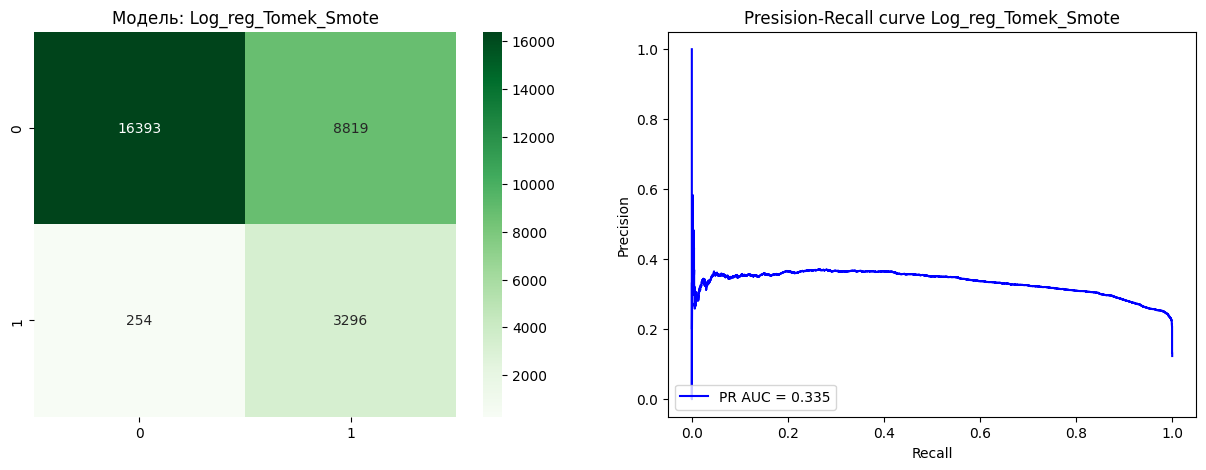

              precision    recall  f1-score   support

           0       0.98      0.65      0.78     25212
           1       0.27      0.93      0.42      3550

    accuracy                           0.68     28762
   macro avg       0.63      0.79      0.60     28762
weighted avg       0.90      0.68      0.74     28762



In [12]:
model_prediction(model=grid_LR_smote, X_tr=X_train_Tomek_Smote, y_tr= y_train_Tomek_Smote, X_ts=X_test, y_ts=y_test, experiment_name='Log_reg_Tomek_Smote')

Исходя из контекста задачи, которая решается - задетектить по максимуму наших клиентов, которые потенциально, положительно отрегают на преждложение, найти их по максимуму. Случаи, когда модель будет ошибочно принимать 0 за 1 можно не считать чем-то ужасным. Все модели показали примерно одинаковый recall у класса 1 - 0.91..0.93 и соответсвенно везде низкий precision. Так же важно обратить внимание, что обе Sampling модели переобучились. 
----

-----
SVC - метод опорных векторов
---

In [13]:
pipeline_SVC_linear = IMBPipeline([
                        ('scaler', StandardScaler()),
                        ('classifier', LinearSVC(max_iter=3000))
                        ])   
grid_params_SVC = {
                   'classifier__C': [0.001, 0.1, 2],
                   'classifier__class_weight': [None, 'balanced']                                                    
                  }

grid_SVC_linear = RandomizedSearchCV(estimator=pipeline_SVC_linear, param_distributions=grid_params_SVC, cv=5,
                                     scoring='f1', n_jobs=-1, verbose=1)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


c:\Users\tsyto\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


{'classifier__class_weight': 'balanced', 'classifier__C': 2}


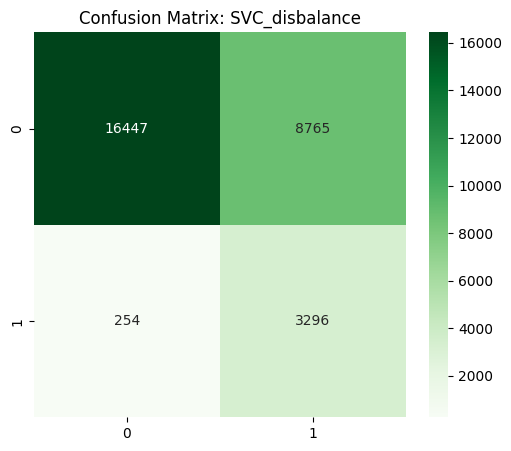

              precision    recall  f1-score   support

           0       0.98      0.65      0.78     25212
           1       0.27      0.93      0.42      3550

    accuracy                           0.69     28762
   macro avg       0.63      0.79      0.60     28762
weighted avg       0.90      0.69      0.74     28762



In [14]:
model_prediction(model=grid_SVC_linear, X_tr=X_train, y_tr=y_train, X_ts=X_test, y_ts=y_test, experiment_name='SVC_disbalance')

Fitting 5 folds for each of 6 candidates, totalling 30 fits


c:\Users\tsyto\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


{'classifier__class_weight': None, 'classifier__C': 2}


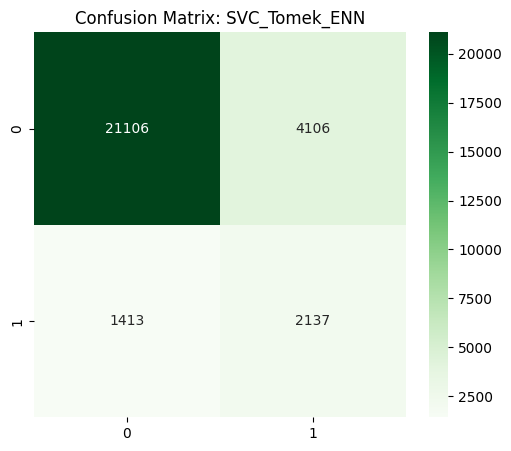

              precision    recall  f1-score   support

           0       0.94      0.84      0.88     25212
           1       0.34      0.60      0.44      3550

    accuracy                           0.81     28762
   macro avg       0.64      0.72      0.66     28762
weighted avg       0.86      0.81      0.83     28762



In [15]:
model_prediction(model=grid_SVC_linear, X_tr=X_train_Tomek_ENN, y_tr= y_train_Tomek_ENN, X_ts=X_test, y_ts=y_test, experiment_name='SVC_Tomek_ENN')

Fitting 5 folds for each of 6 candidates, totalling 30 fits


c:\Users\tsyto\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


{'classifier__class_weight': None, 'classifier__C': 0.1}


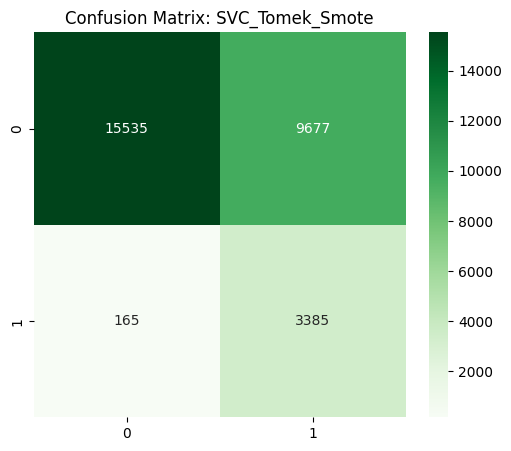

              precision    recall  f1-score   support

           0       0.99      0.62      0.76     25212
           1       0.26      0.95      0.41      3550

    accuracy                           0.66     28762
   macro avg       0.62      0.78      0.58     28762
weighted avg       0.90      0.66      0.72     28762



In [16]:
model_prediction(model=grid_SVC_linear, X_tr=X_train_Tomek_Smote, y_tr= y_train_Tomek_Smote, X_ts=X_test, y_ts=y_test, experiment_name='SVC_Tomek_Smote')

In [17]:
df_results = pd.DataFrame(results_table)
df_results.sort_values(by='Recall', ascending=False, inplace=True)
df_results

,Experiment,Train_Acc,Test_Acc,Precision,Recall,F1_Score,ROC_AUC
5,SVC_Tomek_Smote,0.835807,0.657812,0.259149,0.953521,0.407537,NaN
2,Log_reg_Tomek_Smote,0.838094,0.684549,0.272059,0.928451,0.420811,0.846842
3,SVC_disbalance,0.692105,0.686427,0.273278,0.928451,0.422266,NaN
1,Log_reg_Tomek_ENN,0.830643,0.689243,0.274069,0.920563,0.422386,0.837140
0,Log_reg_disbalance,0.712213,0.707705,0.284688,0.904507,0.433070,0.846995
4,SVC_Tomek_ENN,0.889155,0.808115,0.342303,0.601972,0.436434,NaN


Все модели, которые обучались на Сэмплированных данных показывают сильное переобучение. Не смотря  на то, что метрики у моделей наназванных как SVC_disbalance и Log_reg_disbalance - этим двум вариантам можно хоть как-то доверять.

----------

In [18]:
#Посмотрим как ДеревоРешений справится с построением модели 
pipeline_DT = IMBPipeline([('scaler', StandardScaler()),    
                            ('classifier', DecisionTreeClassifier(class_weight='balanced', random_state=0))]
                            )

param_grid_DT = {
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__max_depth': [15,18,22,25],
    'classifier__min_samples_split': [2, 3, 5],
    'classifier__min_samples_leaf': [1, 2, 5, 10],
    'classifier__max_features': ['sqrt'],
    'classifier__ccp_alpha': [0.001, 0.0001, 0.005]
                }
grid_DT = RandomizedSearchCV(
    estimator=pipeline_DT,
    param_distributions=param_grid_DT,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=2
        )

Fitting 5 folds for each of 10 candidates, totalling 50 fits
{'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 1, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 22, 'classifier__criterion': 'entropy', 'classifier__ccp_alpha': 0.005}


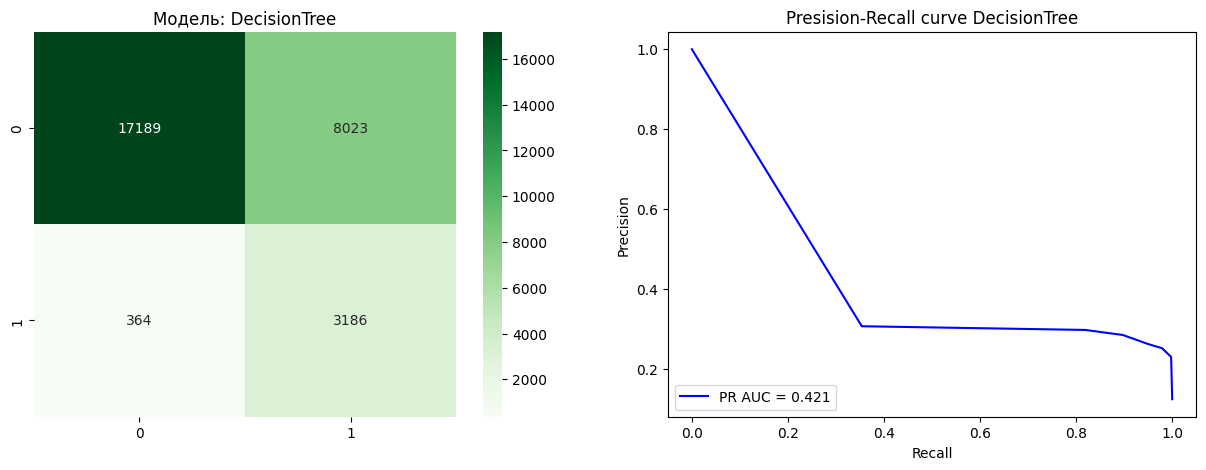

              precision    recall  f1-score   support

           0       0.98      0.68      0.80     25212
           1       0.28      0.90      0.43      3550

    accuracy                           0.71     28762
   macro avg       0.63      0.79      0.62     28762
weighted avg       0.89      0.71      0.76     28762



In [19]:
model_prediction(model=grid_DT, X_tr=X_train, y_tr= y_train, X_ts=X_test, y_ts=y_test, experiment_name='DecisionTree')

Fitting 5 folds for each of 10 candidates, totalling 50 fits
{'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 1, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 25, 'classifier__criterion': 'entropy', 'classifier__ccp_alpha': 0.0001}


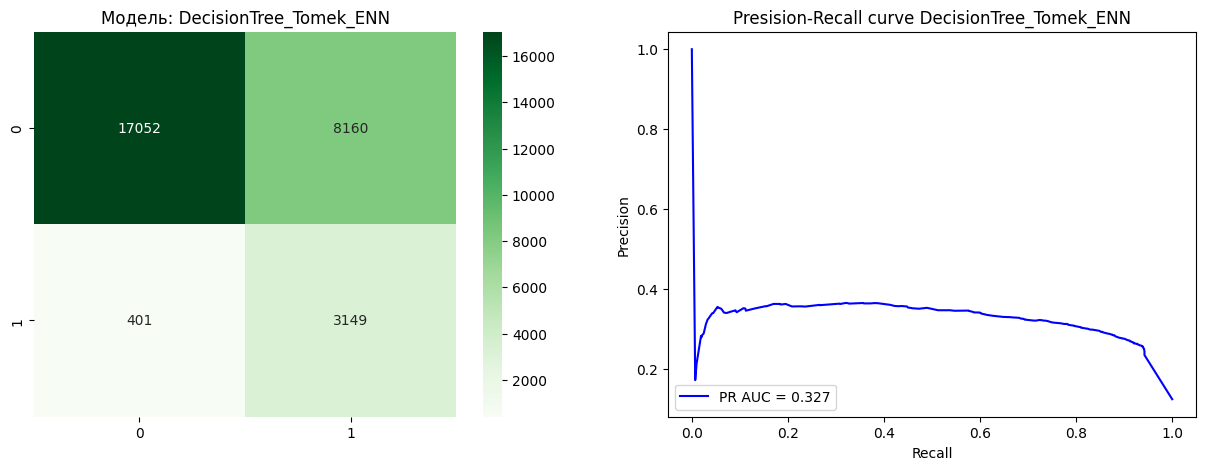

              precision    recall  f1-score   support

           0       0.98      0.68      0.80     25212
           1       0.28      0.89      0.42      3550

    accuracy                           0.70     28762
   macro avg       0.63      0.78      0.61     28762
weighted avg       0.89      0.70      0.75     28762



In [20]:
model_prediction(model=grid_DT, X_tr=X_train_Tomek_ENN, y_tr=y_train_Tomek_ENN, X_ts=X_test, y_ts=y_test, experiment_name='DecisionTree_Tomek_ENN')

In [21]:
df_results = pd.DataFrame(results_table)
df_results.sort_values(by='Recall', ascending=False, inplace=True)
df_results

,Experiment,Train_Acc,Test_Acc,Precision,Recall,F1_Score,ROC_AUC
5,SVC_Tomek_Smote,0.835807,0.657812,0.259149,0.953521,0.407537,NaN
3,SVC_disbalance,0.692105,0.686427,0.273278,0.928451,0.422266,NaN
2,Log_reg_Tomek_Smote,0.838094,0.684549,0.272059,0.928451,0.420811,0.846842
1,Log_reg_Tomek_ENN,0.830643,0.689243,0.274069,0.920563,0.422386,0.837140
0,Log_reg_disbalance,0.712213,0.707705,0.284688,0.904507,0.433070,0.846995
6,DecisionTree,0.711958,0.708400,0.284236,0.897465,0.431737,0.827412
7,DecisionTree_Tomek_ENN,0.866994,0.702350,0.278451,0.887042,0.423851,0.826277
4,SVC_Tomek_ENN,0.889155,0.808115,0.342303,0.601972,0.436434,NaN


In [22]:
from sklearn.ensemble import RandomForestClassifier

In [23]:
pipeline_RF = IMBPipeline([('scaler', StandardScaler()),    
                            ('classifier', RandomForestClassifier(random_state=15, bootstrap=True))]
                            )

param_grid_RF = {
    'classifier__n_estimators': [200, 300],
    'classifier__max_depth': [ 12, 15, 20],
    'classifier__min_samples_split': [3, 5, 7],
    'classifier__min_samples_leaf': [ 10, 20],
    'classifier__max_features': ['sqrt'],
    'classifier__ccp_alpha': [0.001, 0.01],
    'classifier__max_samples': [0.7, 0.9],
    'classifier__class_weight': ['balanced', 'balanced_subsample']   
}

grid_RF = RandomizedSearchCV(
    estimator=pipeline_RF,
    param_distributions=param_grid_RF,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=2
        )

Fitting 5 folds for each of 10 candidates, totalling 50 fits
{'classifier__n_estimators': 300, 'classifier__min_samples_split': 7, 'classifier__min_samples_leaf': 10, 'classifier__max_samples': 0.7, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 12, 'classifier__class_weight': 'balanced_subsample', 'classifier__ccp_alpha': 0.001}


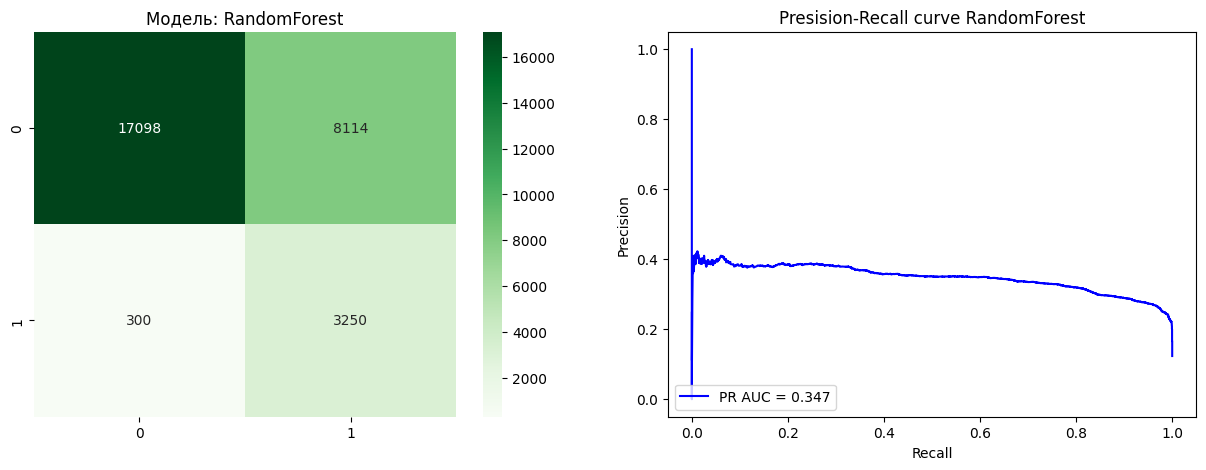

              precision    recall  f1-score   support

           0       0.98      0.68      0.80     25212
           1       0.29      0.92      0.44      3550

    accuracy                           0.71     28762
   macro avg       0.63      0.80      0.62     28762
weighted avg       0.90      0.71      0.76     28762



In [24]:
model_prediction(model=grid_RF, X_tr=X_train, y_tr= y_train, X_ts=X_test, y_ts=y_test, experiment_name='RandomForest')

In [26]:
param_grid_RF_1 = {
    'classifier__n_estimators': [200, 300],
    'classifier__max_depth': [ 12, 15, 20],
    'classifier__min_samples_split': [3, 5, 7],
    'classifier__min_samples_leaf': [ 10, 20],
    'classifier__max_features': ['sqrt'],
    'classifier__ccp_alpha': [0.001, 0.01],
    'classifier__max_samples': [0.7, 0.8, 0.9],
    'classifier__class_weight': [None]   
}

grid_RF_1 = RandomizedSearchCV(
    estimator=pipeline_RF,
    param_distributions=param_grid_RF_1,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=2
        )

Fitting 5 folds for each of 10 candidates, totalling 50 fits
{'classifier__n_estimators': 200, 'classifier__min_samples_split': 7, 'classifier__min_samples_leaf': 20, 'classifier__max_samples': 0.8, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 12, 'classifier__class_weight': None, 'classifier__ccp_alpha': 0.001}


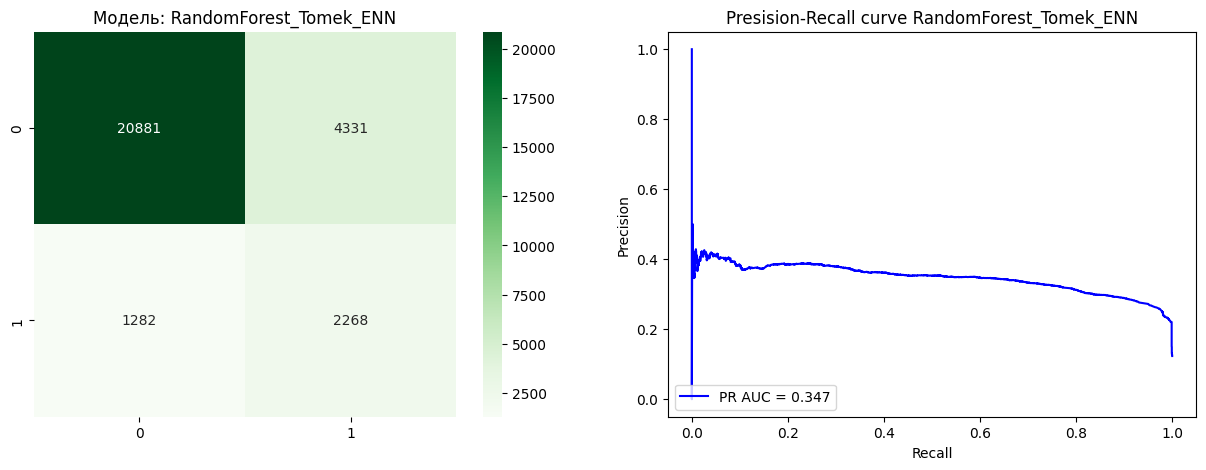

              precision    recall  f1-score   support

           0       0.94      0.83      0.88     25212
           1       0.34      0.64      0.45      3550

    accuracy                           0.80     28762
   macro avg       0.64      0.73      0.66     28762
weighted avg       0.87      0.80      0.83     28762



In [27]:
model_prediction(model=grid_RF_1, X_tr=X_train_Tomek_ENN, y_tr= y_train_Tomek_ENN, X_ts=X_test, y_ts=y_test, experiment_name='RandomForest_Tomek_ENN')

Fitting 5 folds for each of 10 candidates, totalling 50 fits
{'classifier__n_estimators': 200, 'classifier__min_samples_split': 3, 'classifier__min_samples_leaf': 20, 'classifier__max_samples': 0.7, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 15, 'classifier__class_weight': None, 'classifier__ccp_alpha': 0.001}


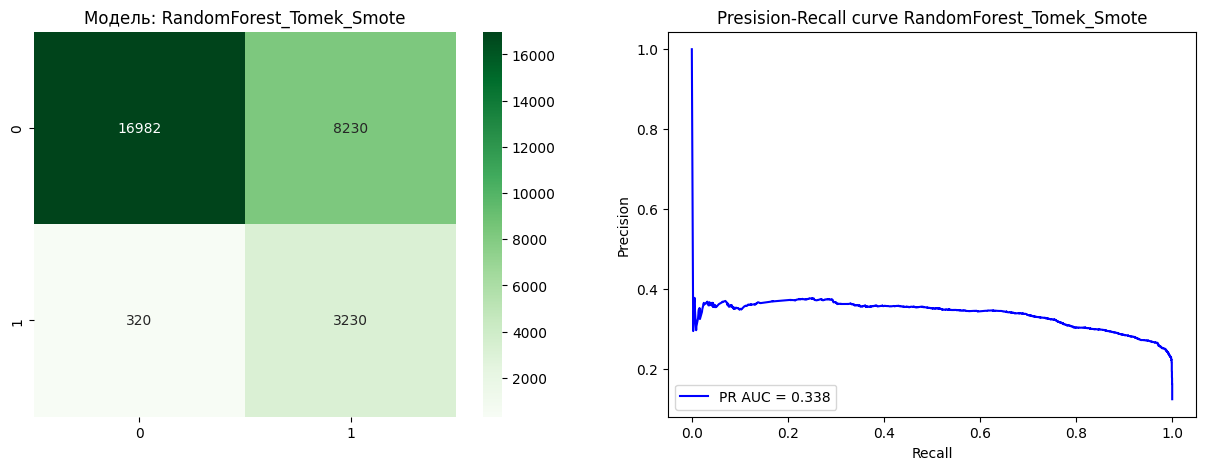

              precision    recall  f1-score   support

           0       0.98      0.67      0.80     25212
           1       0.28      0.91      0.43      3550

    accuracy                           0.70     28762
   macro avg       0.63      0.79      0.61     28762
weighted avg       0.90      0.70      0.75     28762



In [28]:
model_prediction(model=grid_RF_1, X_tr=X_train_Tomek_Smote, y_tr= y_train_Tomek_Smote, X_ts=X_test, y_ts=y_test, experiment_name='RandomForest_Tomek_Smote')

In [ ]:
df_results = pd.DataFrame(results_table)
df_results.sort_values(by='Recall', ascending=False, inplace=True)
df_results 

,Experiment,Train_Acc,Test_Acc,Precision,Recall,F1_Score,ROC_AUC
5,SVC_Tomek_Smote,0.835807,0.657812,0.259149,0.953521,0.407537,NaN
3,SVC_disbalance,0.692105,0.686427,0.273278,0.928451,0.422266,NaN
2,Log_reg_Tomek_Smote,0.838094,0.684549,0.272059,0.928451,0.420811,0.846842
1,Log_reg_Tomek_ENN,0.830643,0.689243,0.274069,0.920563,0.422386,0.837140
8,RandomForest,0.711008,0.707461,0.285991,0.915493,0.435832,0.851615
10,RandomForest_Tomek_Smote,0.846356,0.702733,0.281850,0.909859,0.430380,0.848232
0,Log_reg_disbalance,0.712213,0.707705,0.284688,0.904507,0.433070,0.846995
6,DecisionTree,0.711958,0.708400,0.284236,0.897465,0.431737,0.827412
7,DecisionTree_Tomek_ENN,0.866994,0.702350,0.278451,0.887042,0.423851,0.826277
9,RandomForest_Tomek_ENN,0.895161,0.804847,0.343688,0.638873,0.446941,0.849698
